# Stroke Prediction — Model Training & Evaluation
**Goal:** Train multiple classifiers on the preprocessed data, compare them fairly, and save the best model.

Notebook order:
1. `01_eda.ipynb` ✓
2. `02_preprocessing.ipynb` ✓
3. `03_model_training.ipynb` ← you are here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'

X_train = pd.read_csv(PROCESSED_PATH + 'X_train.csv')
y_train = pd.read_csv(PROCESSED_PATH + 'y_train.csv').squeeze()
X_test  = pd.read_csv(PROCESSED_PATH + 'X_test.csv')
y_test  = pd.read_csv(PROCESSED_PATH + 'y_test.csv').squeeze()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')

Train: (7776, 10), Test: (1022, 10)
Train class balance: {0: 3888, 1: 3888}


---
## 1. Define models

In [2]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}
print(f'{len(models)} models defined')

5 models defined


---
## 2. Cross-validation comparison
We use 5-fold stratified cross-validation on the training set. ROC-AUC is the primary metric for imbalanced medical data — it measures the model's ability to distinguish stroke from non-stroke regardless of threshold.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression        ROC-AUC: 0.8897 ± 0.0040
Decision Tree              ROC-AUC: 0.9075 ± 0.0069
Random Forest              ROC-AUC: 0.9901 ± 0.0014
Gradient Boosting          ROC-AUC: 0.9683 ± 0.0022
XGBoost                    ROC-AUC: 0.9913 ± 0.0006


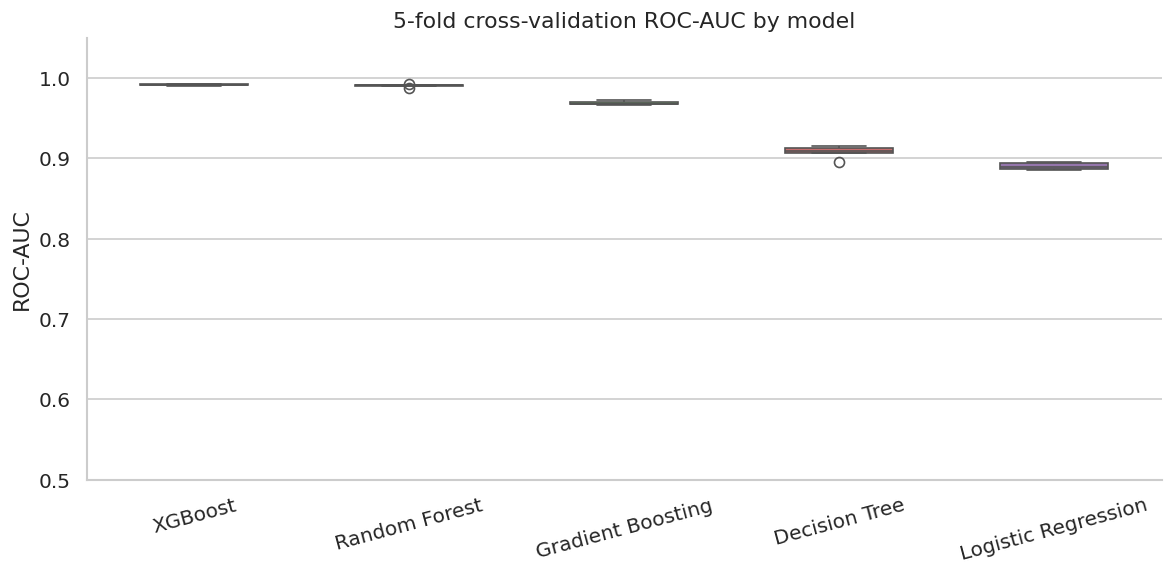

In [4]:
cv_df = pd.DataFrame(cv_results).melt(var_name='Model', value_name='ROC-AUC')

fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(cv_results, key=lambda k: np.mean(cv_results[k]), reverse=True)
sns.boxplot(data=cv_df, x='Model', y='ROC-AUC', order=order,
            palette='muted', width=0.5, ax=ax)
ax.set_title('5-fold cross-validation ROC-AUC by model')
ax.set_xlabel('')
ax.set_ylabel('ROC-AUC')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'training_cv_comparison.png', bbox_inches='tight')
plt.show()

---
## 3. Train all models on full training set and evaluate on test set

In [5]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred),
        'ROC-AUC':  roc_auc_score(y_test, y_proba),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df = results_df.set_index('Model')
results_df = results_df.round(4)
print('Test set performance:')
print(results_df)

Test set performance:
                     Accuracy      F1  ROC-AUC
Model                                         
Logistic Regression    0.7671  0.2323   0.7823
Gradient Boosting      0.8415  0.2212   0.7800
Random Forest          0.8943  0.1429   0.7667
XGBoost                0.8924  0.1270   0.7635
Decision Tree          0.8611  0.1013   0.5286


---
## 4. ROC curves — all models

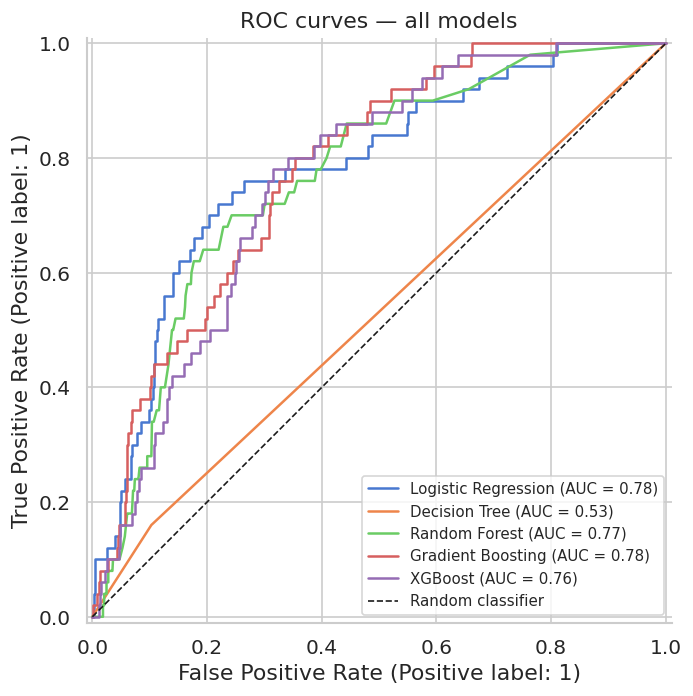

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC curves — all models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'training_roc_curves.png', bbox_inches='tight')
plt.show()

---
## 5. Select best model

In [7]:
best_name  = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_name]
best_auc   = results_df.loc[best_name, 'ROC-AUC']
best_f1    = results_df.loc[best_name, 'F1']

print(f'Best model : {best_name}')
print(f'ROC-AUC    : {best_auc:.4f}')
print(f'F1 score   : {best_f1:.4f}')

Best model : Logistic Regression
ROC-AUC    : 0.7823
F1 score   : 0.2323


---
## 6. Confusion matrix — best model

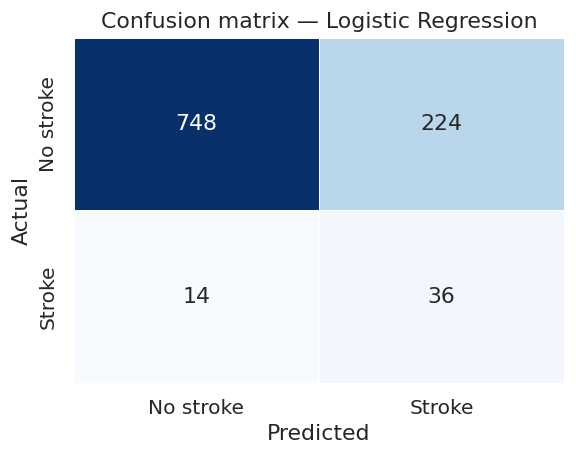


Classification report:
              precision    recall  f1-score   support

   No stroke       0.98      0.77      0.86       972
      Stroke       0.14      0.72      0.23        50

    accuracy                           0.77      1022
   macro avg       0.56      0.74      0.55      1022
weighted avg       0.94      0.77      0.83      1022



In [8]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No stroke', 'Stroke'],
            yticklabels=['No stroke', 'Stroke'],
            linewidths=0.5, cbar=False)
ax.set_title(f'Confusion matrix — {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(PROCESSED_PATH + 'training_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nClassification report:')
print(classification_report(y_test, y_pred_best, target_names=['No stroke', 'Stroke']))

---
## 7. Feature importance — best model

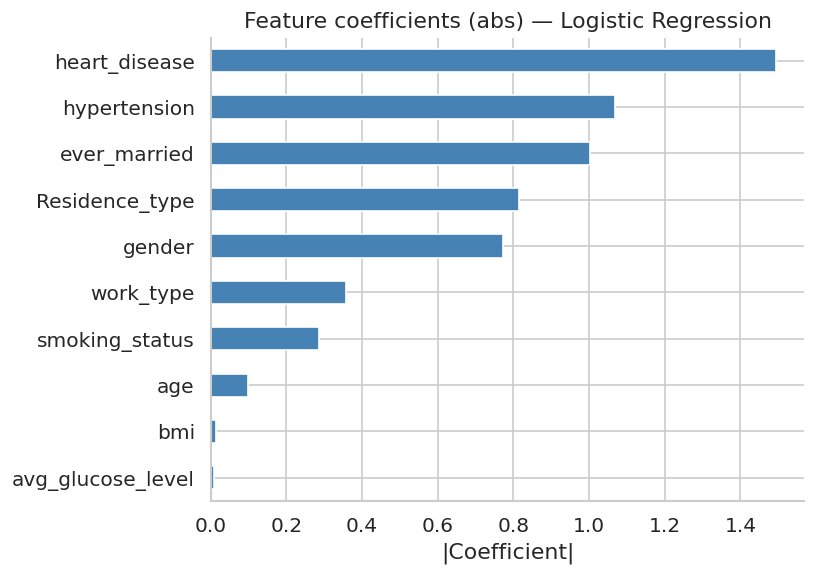

In [9]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(PROCESSED_PATH + 'training_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    # Logistic Regression — use coefficients instead
    coefs = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)
    coefs = coefs.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    coefs.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature coefficients (abs) — {best_name}')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.savefig(PROCESSED_PATH + 'training_feature_importance.png', bbox_inches='tight')
    plt.show()

---
## 8. Save best model

In [10]:
model_save_path = MODELS_PATH + 'model.pkl'
joblib.dump(best_model, model_save_path)
print(f'Saved: {model_save_path}')
print(f'Model: {best_name}')

Saved: ../models/model.pkl
Model: Logistic Regression


---
## 9. Final summary

In [11]:
print('=' * 55)
print('MODEL TRAINING SUMMARY')
print('=' * 55)
print()
print('All models (sorted by ROC-AUC):')
print(results_df.to_string())
print()
print(f'Winner          : {best_name}')
print(f'ROC-AUC         : {best_auc:.4f}')
print(f'F1 score        : {best_f1:.4f}')
print()
print('Saved to models/')
print('  model.pkl          ← load this in app.py')
print('  bmi_imputer.pkl')
print('  label_encoders.pkl')
print()
print('Next step: update app.py to use utils/preprocessing.py')
print('=' * 55)

MODEL TRAINING SUMMARY

All models (sorted by ROC-AUC):
                     Accuracy      F1  ROC-AUC
Model                                         
Logistic Regression    0.7671  0.2323   0.7823
Gradient Boosting      0.8415  0.2212   0.7800
Random Forest          0.8943  0.1429   0.7667
XGBoost                0.8924  0.1270   0.7635
Decision Tree          0.8611  0.1013   0.5286

Winner          : Logistic Regression
ROC-AUC         : 0.7823
F1 score        : 0.2323

Saved to models/
  model.pkl          ← load this in app.py
  bmi_imputer.pkl
  label_encoders.pkl

Next step: update app.py to use utils/preprocessing.py
